# Kaggle PROSTATE_MRI Auto-Segmentation QC

Visual inspection notebook for the actual assignment output. It loads the converted Kaggle axial T2 NIfTI images and the nnU-Net Dataset502 auto-segmented anatomy masks.

These masks are model predictions, not manual labels. The Kaggle data in this workspace does not include ground-truth prostate masks, so this notebook is for visual QC rather than Dice evaluation.

In [1]:
from pathlib import Path
import csv

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "data").exists():
            PROJECT_ROOT = parent
            break

MANIFEST_PATH = PROJECT_ROOT / "data/manifests/kaggle_prostate_mri_t2_manifest.csv"
IMAGE_DIR = PROJECT_ROOT / "data/interim/kaggle_prostate_mri_t2_nifti/imagesTs"
PREDICTION_DIR = PROJECT_ROOT / "outputs/predictions/kaggle_prostate_mri_anatomy_auto"
QC_DIR = PROJECT_ROOT / "outputs/figures/qc/kaggle_prostate_mri_auto_segmentations"

with MANIFEST_PATH.open("r", newline="", encoding="utf-8") as f:
    rows = list(csv.DictReader(f))

image_paths = sorted(IMAGE_DIR.glob("*_0000.nii.gz"))
prediction_paths = sorted(PREDICTION_DIR.glob("*.nii.gz"))
qc_paths = sorted(QC_DIR.glob("*.png"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Manifest rows: {len(rows)}")
print(f"Converted T2 images: {len(image_paths)}")
print(f"Auto-segmentation masks: {len(prediction_paths)}")
print(f"QC PNGs: {len(qc_paths)}")

Project root: /home/eddy/Downloads/sirharginger/prostate-mri-cancer-detection
Manifest rows: 26
Converted T2 images: 26
Auto-segmentation masks: 26
QC PNGs: 26


In [3]:
def load_nifti(path):
    img = nib.load(str(path))
    return img, np.asanyarray(img.dataobj)


def choose_mask_slice(mask):
    if mask.ndim != 3:
        raise ValueError(f"Expected 3D mask, got shape {mask.shape}")
    z_counts = (mask > 0).reshape(-1, mask.shape[-1]).sum(axis=0)
    if int(z_counts.max()) == 0:
        return mask.shape[-1] // 2
    return int(np.argmax(z_counts))


def window_image(image_slice):
    low, high = np.percentile(image_slice, [1, 99])
    if high <= low:
        return image_slice
    return np.clip((image_slice - low) / (high - low), 0, 1)


def overlay_prediction(axis, mask_slice):
    rotated = np.rot90(mask_slice)
    label_1 = np.ma.masked_where(rotated != 1, rotated)
    label_2 = np.ma.masked_where(rotated != 2, rotated)
    axis.imshow(label_1, cmap="spring", alpha=0.35, vmin=0, vmax=2)
    axis.imshow(label_2, cmap="winter", alpha=0.35, vmin=0, vmax=2)


def show_case(row, slice_index=None):
    case_id = row["case_id"]
    image_path = PROJECT_ROOT / row["image_path"]
    prediction_path = PREDICTION_DIR / f"{case_id}.nii.gz"
    image_img, image = load_nifti(image_path)
    pred_img, prediction = load_nifti(prediction_path)

    if image.shape != prediction.shape:
        raise ValueError(f"Shape mismatch for {case_id}: {image.shape} vs {prediction.shape}")

    if slice_index is None:
        slice_index = choose_mask_slice(prediction)

    values = sorted(np.unique(prediction).astype(int).tolist())
    image_slice = window_image(image[:, :, slice_index])
    mask_slice = prediction[:, :, slice_index]

    fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
    axes[0].imshow(np.rot90(image_slice), cmap="gray")
    axes[0].set_title(f"{case_id} T2 slice {slice_index}")
    axes[0].axis("off")

    axes[1].imshow(np.rot90(image_slice), cmap="gray")
    overlay_prediction(axes[1], mask_slice)
    axes[1].set_title(f"Auto mask values {values}")
    axes[1].axis("off")

    print(f"{case_id}: image shape={image.shape}, spacing={image_img.header.get_zooms()[:3]}, prediction values={values}")
    return fig

mip_prostate_01_0001: image shape=(512, 512, 26), spacing=(np.float32(0.2734375), np.float32(0.2734375), np.float32(2.9999998)), prediction values=[0, 1, 2]


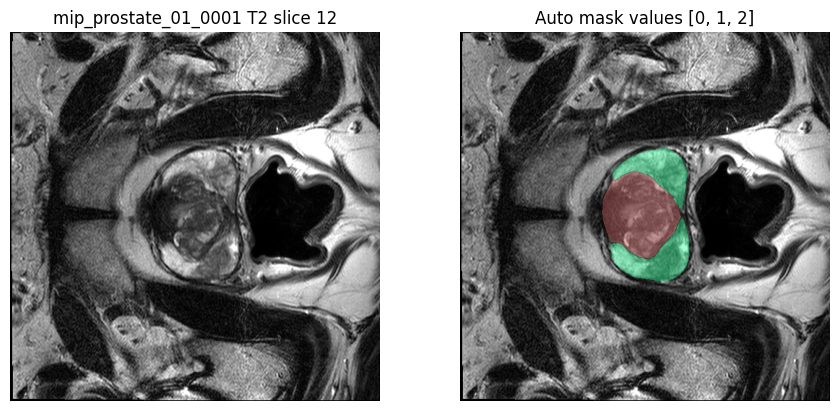

mip_prostate_01_0002: image shape=(512, 512, 26), spacing=(np.float32(0.2734375), np.float32(0.2734375), np.float32(3.0)), prediction values=[0, 1, 2]


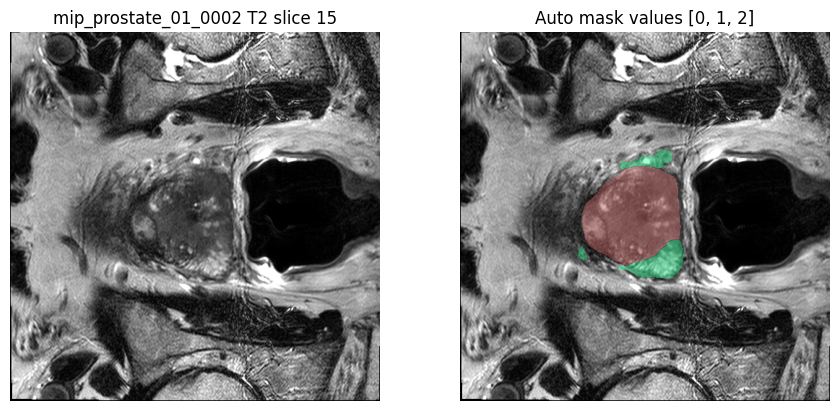

mip_prostate_01_0003: image shape=(512, 512, 26), spacing=(np.float32(0.2734375), np.float32(0.2734375), np.float32(2.9999995)), prediction values=[0, 1, 2]


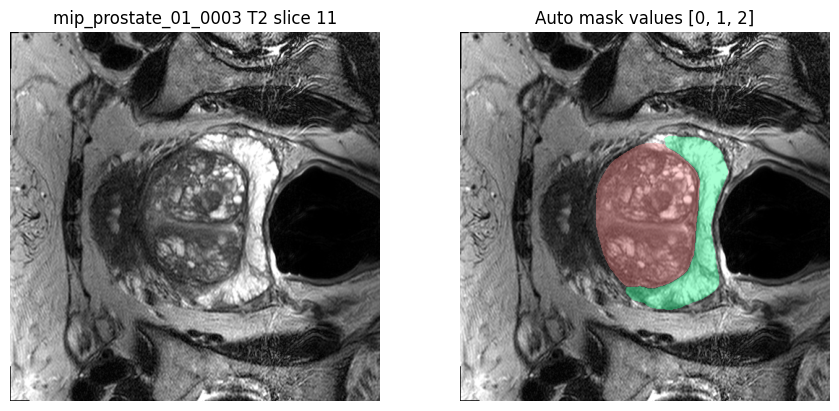

mip_prostate_01_0004: image shape=(512, 512, 26), spacing=(np.float32(0.2734375), np.float32(0.2734375), np.float32(3.0)), prediction values=[0, 1, 2]


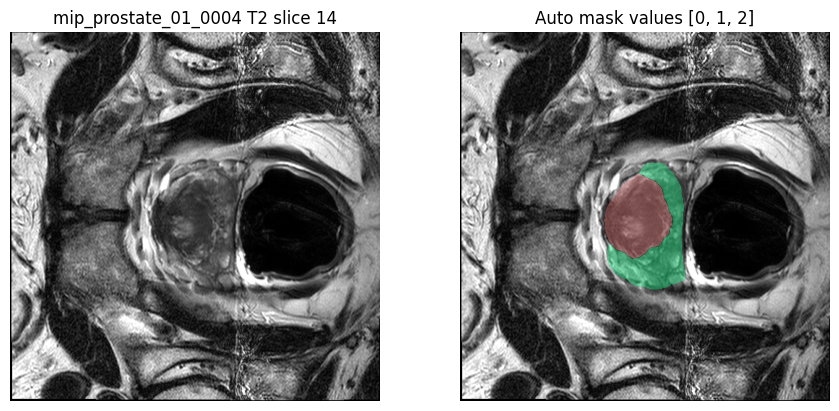

mip_prostate_01_0005: image shape=(512, 512, 26), spacing=(np.float32(0.2734375), np.float32(0.2734375), np.float32(3.0000002)), prediction values=[0, 1, 2]


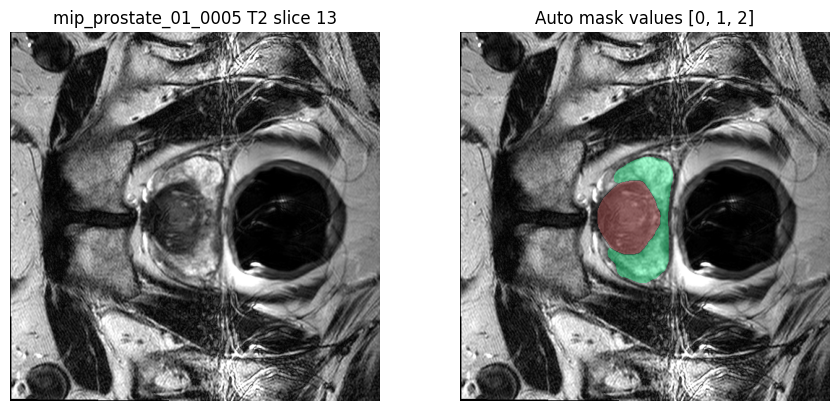

mip_prostate_01_0006: image shape=(512, 512, 26), spacing=(np.float32(0.2734375), np.float32(0.2734375), np.float32(3.0000002)), prediction values=[0, 1, 2]


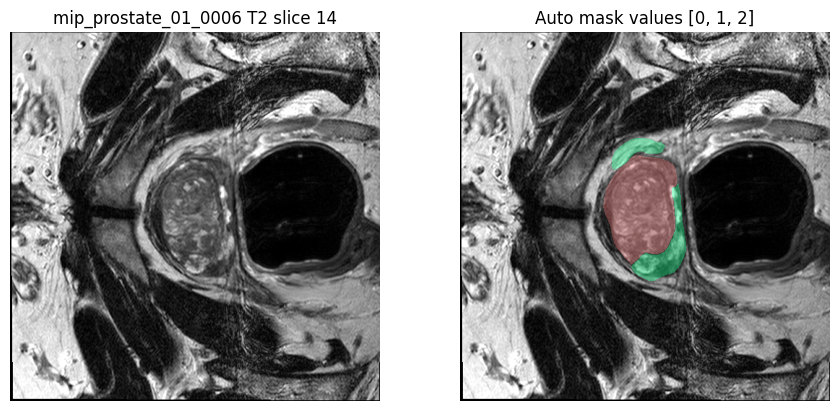

In [4]:
for row in rows[:6]:
    show_case(row)
    plt.show()

## Inspect One Case

Change `case_index` to inspect another case. Leave `slice_index = None` to automatically choose the slice with the largest predicted mask.

mip_prostate_01_0001: image shape=(512, 512, 26), spacing=(np.float32(0.2734375), np.float32(0.2734375), np.float32(2.9999998)), prediction values=[0, 1, 2]


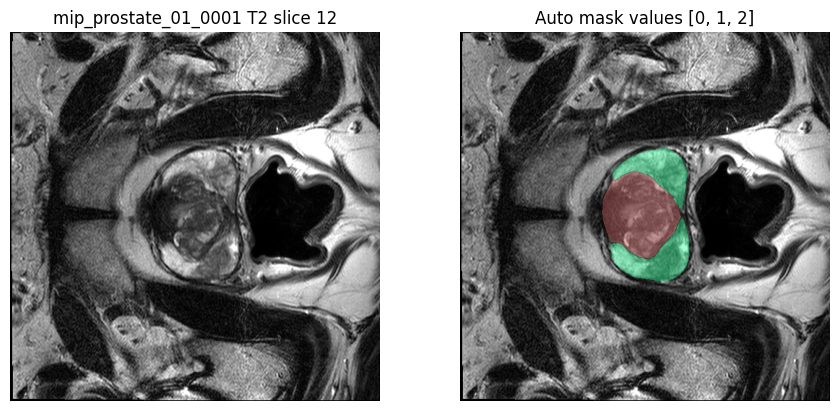

In [5]:
case_index = 0
slice_index = None

show_case(rows[case_index], slice_index=slice_index)
plt.show()

## Output Locations

The auto-segmentation masks are stored in `outputs/predictions/kaggle_prostate_mri_anatomy_auto/`.

The presentation-ready PNG overlays are stored in `outputs/figures/qc/kaggle_prostate_mri_auto_segmentations/`.